In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

from process_and_save_recording import load_recording, combine_accel_gyro, add_annotations_to_combined, add_predictions_to_combined

# Load recording

In [2]:
# session_1776422910441
path = "session_1779544010630"
accel, gyro, classification, annotations, info = load_recording(path)
accel.shape, gyro.shape, classification.shape, annotations.keys(), len(annotations["events"]), info

((192297, 4),
 (192297, 4),
 (3825, 6),
 dict_keys(['phoneStartTimestamp', 'phoneEndTimestamp', 'events']),
 16,
 ['start_time=1779544010959',
  'phone_timestamp=1779544010630',
  'end_time=1779547864089'])

In [3]:
accel

,timestamp,x,y,z
0,88195557365381,-2.719813,-9.619903,-1.640028
1,88195577369342,-2.703054,-9.299079,-1.704672
2,88195597372688,-2.703054,-9.047688,-1.766921
3,88195617381034,-2.767697,-9.334992,-2.023100
4,88195639398150,-2.832341,-9.112331,-2.047042
...,...,...,...,...
192292,92048587083069,-1.027113,-8.714894,-0.694318
192293,92048607087492,-0.577003,-8.808268,-0.746991
192294,92048627650954,-0.426168,-8.765172,-0.205901
192295,92048648629454,-1.211466,-8.111555,-0.179565


In [4]:
gyro

,timestamp,x,y,z
0,88195557367727,-0.109956,-0.018326,0.012217
1,88195577371919,0.064752,-0.017104,0.015882
2,88195597374996,0.009774,-0.021991,0.006109
3,88195617383611,-0.064752,-0.045204,0.020769
4,88195639400496,-0.094073,-0.068417,0.017104
...,...,...,...,...
192292,92048587085262,0.929737,-0.004887,-0.001222
192293,92048607089915,0.678060,0.014661,0.144164
192294,92048627653146,0.496023,0.114843,0.103847
192295,92048648631915,0.541227,0.001222,0.224798


In [5]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1779544011957,0.006821,0,88194536854385;88194556884538;88194576868961;8...,88194536856962;88194556886885;88194576871538;8...,-2.920926|-9.270349|-1.6136919|-0.02076942|0.0...
1,1779544012967,0.015665,0,88195537356304;88195557365381;88195577369342;8...,88195537358881;88195557367727;88195577371919;8...,-2.8682537|-9.361329|-2.2529438|-0.073303826|0...
2,1779544013972,0.034424,0,88196558458185;88196578473108;88196600498261;8...,88196558460492;88196578475685;88196600502531;8...,-2.8874073|-9.248801|-1.4341269|0.014660766|-0...
3,1779544014980,0.015588,0,88197562352258;88197580345065;88197600331796;8...,88197562354604;88197580347642;88197600334104;8...,-2.5785553|-9.186552|-1.448492|0.35063666|0.01...
4,1779544015991,0.011809,0,88198564030562;88198584109831;88198604190908;8...,88198564032869;88198584112408;88198604193215;8...,-2.7246015|-9.172187|-2.1164744|0.19547687|-0....
...,...,...,...,...,...,...
3820,1779547859911,0.384556,0,92042490578477;92042510670131;92042531312016;9...,92042490580670;92042510672554;92042531314208;9...,7.4866686|-3.6224272|1.3335704|-1.7104226|0.76...
3821,1779547860915,0.062705,0,92043494462627;92043515499243;92043534072512;9...,92043494464820;92043515501704;92043534074704;9...,12.674904|-4.5441947|-0.81642276|-1.6334536|0....
3822,1779547861922,0.025905,0,92044517093316;92044537178316;92044557260739;9...,92044517095777;92044537180508;92044557263162;9...,7.66384|-4.24492|-0.91697925|1.46852|-0.568104...
3823,1779547862912,0.005798,0,92045519885043;92045539958389;92045560030658;9...,92045519887466;92045539960581;92045560033081;9...,11.192893|-9.435549|2.6072857|2.9492574|-1.634...


In [6]:
annotations

{'phoneStartTimestamp': 1779544010630,
 'phoneEndTimestamp': 1779547864081,
 'events': [{'name': 'Cable Ab Crunch',
   'startTime': 1779547675748,
   'endTime': 1779547721314},
  {'name': 'Cable Ab Crunch',
   'startTime': 1779547446546,
   'endTime': 1779547486087},
  {'name': 'Bench Press',
   'startTime': 1779547097946,
   'endTime': 1779547126955},
  {'name': 'Bench Press',
   'startTime': 1779546779751,
   'endTime': 1779546802287},
  {'name': 'Lateral Raises ',
   'startTime': 1779546564614,
   'endTime': 1779546597171},
  {'name': 'Lateral Raises ',
   'startTime': 1779546349980,
   'endTime': 1779546380694},
  {'name': 'Pulldowns', 'startTime': 1779546235338, 'endTime': 1779546266672},
  {'name': 'Pulldowns', 'startTime': 1779545993430, 'endTime': 1779546027300},
  {'name': 'Cable Overhead Extension',
   'startTime': 1779545799341,
   'endTime': 1779545836358},
  {'name': 'Cable Overhead Extensions',
   'startTime': 1779545597976,
   'endTime': 1779545634440},
  {'name': 'Hamme

In [7]:
info

['start_time=1779544010959',
 'phone_timestamp=1779544010630',
 'end_time=1779547864089']

# Sanity check recording

## Start and end timestamps

In [8]:
def print_recording_stats(accel, gyro, classification, annotations, info):
    phone_start_timestamp = annotations["phoneStartTimestamp"]
    phone_end_timestamp = annotations["phoneEndTimestamp"]
    watch_start_timestamp = int(info[0].split('=')[1])
    watch_end_timestamp = int(info[2].split('=')[1])
    print(f"Phone start timestamp:\t {phone_start_timestamp}\t ({pd.to_datetime(phone_start_timestamp, unit='ms')})")
    print(f"Phone end timestamp:\t {phone_end_timestamp}\t ({pd.to_datetime(phone_end_timestamp, unit='ms')})")
    print("Duration of phone recording:", pd.to_timedelta(phone_end_timestamp - phone_start_timestamp, unit='ms'))
    print(f"Watch start timestamp:\t {watch_start_timestamp}\t ({pd.to_datetime(watch_start_timestamp, unit='ms')})")
    print(f"Watch end timestamp:\t {watch_end_timestamp}\t ({pd.to_datetime(watch_end_timestamp, unit='ms')})")
    print("Duration of watch recording:", pd.to_timedelta(watch_end_timestamp - watch_start_timestamp, unit='ms'))
    print("Duration difference between phone and watch recordings (ms):", (phone_end_timestamp - phone_start_timestamp) - (watch_end_timestamp - watch_start_timestamp))
    print("Difference between phone and watch start timestamps (ms):", phone_start_timestamp - watch_start_timestamp)
    print("Difference between phone and watch end timestamps (ms):", phone_end_timestamp - watch_end_timestamp)

In [9]:
print_recording_stats(accel, gyro, classification, annotations, info)

Phone start timestamp:	 1779544010630	 (2026-05-23 13:46:50.630000)
Phone end timestamp:	 1779547864081	 (2026-05-23 14:51:04.081000)
Duration of phone recording: 0 days 01:04:13.451000
Watch start timestamp:	 1779544010959	 (2026-05-23 13:46:50.959000)
Watch end timestamp:	 1779547864089	 (2026-05-23 14:51:04.089000)
Duration of watch recording: 0 days 01:04:13.130000
Duration difference between phone and watch recordings (ms): 321
Difference between phone and watch start timestamps (ms): -329
Difference between phone and watch end timestamps (ms): -8


In [10]:
def print_recording_imu_stats(accel, gyro):
    # accel, gyro timestamps are in nanoseconds
    print(f"First accel timestamp:\t {accel['timestamp'][0]}\t ({pd.to_datetime(accel['timestamp'][0], unit='ns')})")
    print(f"First gyro timestamp:\t {gyro['timestamp'][0]}\t ({pd.to_datetime(gyro['timestamp'][0], unit='ns')})")
    print("Duration of accel recording:", pd.to_timedelta(accel['timestamp'].iloc[-1] - accel['timestamp'][0], unit='ns'))
    print(f"Last accel timestamp:\t {accel['timestamp'].iloc[-1]}\t ({pd.to_datetime(accel['timestamp'].iloc[-1], unit='ns')})")
    print(f"Last gyro timestamp:\t {gyro['timestamp'].iloc[-1]}\t ({pd.to_datetime(gyro['timestamp'].iloc[-1], unit='ns')})")
    print("Duration of gyro recording:", pd.to_timedelta(gyro['timestamp'].iloc[-1] - gyro['timestamp'][0], unit='ns'))
    print("Duration difference between accel and gyro recordings (ns):", (accel['timestamp'].iloc[-1] - accel['timestamp'][0]) - (gyro['timestamp'].iloc[-1] - gyro['timestamp'][0]))
    print("Difference between accel and gyro start timestamps (ns):", accel['timestamp'][0] - gyro['timestamp'][0])
    print("Difference between accel and gyro end timestamps (ns):", accel['timestamp'].iloc[-1] - gyro['timestamp'].iloc[-1])

In [11]:
print_recording_imu_stats(accel, gyro)

First accel timestamp:	 88195557365381	 (1970-01-02 00:29:55.557365381)
First gyro timestamp:	 88195557367727	 (1970-01-02 00:29:55.557367727)
Duration of accel recording: 0 days 01:04:13.109780727
Last accel timestamp:	 92048667146108	 (1970-01-02 01:34:08.667146108)
Last gyro timestamp:	 92048667148300	 (1970-01-02 01:34:08.667148300)
Duration of gyro recording: 0 days 01:04:13.109780573
Duration difference between accel and gyro recordings (ns): 154
Difference between accel and gyro start timestamps (ns): -2346
Difference between accel and gyro end timestamps (ns): -2192


## Sorted? Duplicates?

In [12]:
# is accel and gyro sorted?
print("Is accel sorted by timestamp?", accel['timestamp'].is_monotonic_increasing)
print("Is gyro sorted by timestamp?", gyro['timestamp'].is_monotonic_increasing)

Is accel sorted by timestamp? True
Is gyro sorted by timestamp? True


In [13]:
# detect duplicates
accel_duplicates = accel[accel.duplicated(subset='timestamp', keep=False)]
gyro_duplicates = gyro[gyro.duplicated(subset='timestamp', keep=False)]
print(f"Number of duplicate timestamps in accel: {len(accel_duplicates)}")
print(f"Number of duplicate timestamps in gyro: {len(gyro_duplicates)}")

Number of duplicate timestamps in accel: 0
Number of duplicate timestamps in gyro: 0


## Differences in rows and sequential rows

In [14]:
# Compare timestamps row by row
def compare_timestamps(accel, gyro, threshold_ms=1):
    for idx in range(len(accel)):
        accel_ts = accel.iloc[idx]['timestamp']
        gyro_ts = gyro.iloc[idx]['timestamp']
        diff = accel_ts - gyro_ts
        if abs(diff) > threshold_ms * 1_000_000:  # Convert ms to nanoseconds
            print(f"Row {idx}: accel={accel_ts}, gyro={gyro_ts}, diff={(diff) / 1_000_000:.2f}ms")

In [15]:
# Are accel and gyro timestamps aligned?
compare_timestamps(accel, gyro, threshold_ms=1)

In [16]:
# Sequential differences between consecutive rows
def print_sequential_differences(accel, gyro, threshold_ms=22):
    print(f"Sequential timestamp differences (>={threshold_ms}ms):")
    for idx in range(len(accel) - 1):
        accel_curr = accel.iloc[idx]['timestamp']
        accel_next = accel.iloc[idx + 1]['timestamp']
        accel_seq_diff_ms = (accel_next - accel_curr) / 1_000_000  # Convert ns to ms
    
        gyro_curr = gyro.iloc[idx]['timestamp']
        gyro_next = gyro.iloc[idx + 1]['timestamp']
        gyro_seq_diff_ms = (gyro_next - gyro_curr) / 1_000_000  # Convert ns to ms
        
        if accel_seq_diff_ms > threshold_ms or gyro_seq_diff_ms > threshold_ms:
            print(f"Row {idx}->{idx+1}: accel_diff={accel_seq_diff_ms:.2f}ms, gyro_diff={gyro_seq_diff_ms:.2f}ms")
            # print out few rows timestamps and time diff around the gap for context
            accels = accel.iloc[max(0, idx-5):min(len(accel), idx+5)][['timestamp']]
            gyros = gyro.iloc[max(0, idx-5):min(len(gyro), idx+5)][['timestamp']]
            print("Accel timestamps around gap:")
            for i, row in accels.iterrows():
                print(f"Row {i}: {row['timestamp']} ({(row['timestamp'] - accel_curr) / 1_000_000:.2f}ms from current)")
            print("Gyro timestamps around gap:")
            for i, row in gyros.iterrows():
                print(f"Row {i}: {row['timestamp']} ({(row['timestamp'] - gyro_curr) / 1_000_000:.2f}ms from current)")

In [17]:
len(accel)

192297

In [18]:
print_sequential_differences(accel, gyro, threshold_ms=25)

Sequential timestamp differences (>=25ms):


## Difference statistics

In [19]:
# Calculate statistics for differences
def calculate_accel_gyro_differences(accel, gyro):
    accel_gyro_diffs_ms = []
    for idx in range(len(accel)):
        accel_ts = accel.iloc[idx]['timestamp']
        gyro_ts = gyro.iloc[idx]['timestamp']
        diff_ms = abs(accel_ts - gyro_ts) / 1_000_000
        accel_gyro_diffs_ms.append(diff_ms)
    return accel_gyro_diffs_ms

def calculate_sequential_differences(accel, gyro):
    accel_seq_diffs_ms = []
    gyro_seq_diffs_ms = []
    for idx in range(len(accel) - 1):
        accel_seq_diff = (accel.iloc[idx + 1]['timestamp'] - accel.iloc[idx]['timestamp']) / 1_000_000
        gyro_seq_diff = (gyro.iloc[idx + 1]['timestamp'] - gyro.iloc[idx]['timestamp']) / 1_000_000
        accel_seq_diffs_ms.append(accel_seq_diff)
        gyro_seq_diffs_ms.append(gyro_seq_diff)
    return accel_seq_diffs_ms, gyro_seq_diffs_ms

def print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms):
    print("=" * 60)
    print("ACCEL-GYRO SYNC DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(accel_gyro_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_gyro_diffs_ms):.4f}ms")
    print(f"Min: {np.min(accel_gyro_diffs_ms):.4f}ms")
    print(f"Max: {np.max(accel_gyro_diffs_ms):.4f}ms")
    print(f"Median: {np.median(accel_gyro_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_gyro_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_gyro_diffs_ms, 75):.4f}ms")

    print("\n" + "=" * 60)
    print("ACCEL SEQUENTIAL DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(accel_seq_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_seq_diffs_ms):.4f}ms")
    print(f"Min: {np.min(accel_seq_diffs_ms):.4f}ms")
    print(f"Max: {np.max(accel_seq_diffs_ms):.4f}ms")
    print(f"Median: {np.median(accel_seq_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_seq_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_seq_diffs_ms, 75):.4f}ms")
    print(f" (95%): {np.percentile(accel_seq_diffs_ms, 99):.4f}ms")

    print("\n" + "=" * 60)
    print("GYRO SEQUENTIAL DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(gyro_seq_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(gyro_seq_diffs_ms):.4f}ms")
    print(f"Min: {np.min(gyro_seq_diffs_ms):.4f}ms")
    print(f"Max: {np.max(gyro_seq_diffs_ms):.4f}ms")
    print(f"Median: {np.median(gyro_seq_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(gyro_seq_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(gyro_seq_diffs_ms, 75):.4f}ms")

def calculate_and_print_difference_stats(accel, gyro):
# Accel-Gyro timestamp differences (sync differences)
    accel_gyro_diffs_ms = calculate_accel_gyro_differences(accel, gyro)
    accel_seq_diffs_ms, gyro_seq_diffs_ms = calculate_sequential_differences(accel, gyro)
    print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms)

In [20]:
calculate_and_print_difference_stats(accel, gyro)

ACCEL-GYRO SYNC DIFFERENCES (ms)
Mean: 0.0023ms
Std Dev: 0.0001ms
Min: 0.0022ms
Max: 0.0097ms
Median: 0.0024ms
Q1 (25%): 0.0022ms
Q3 (75%): 0.0024ms

ACCEL SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0374ms
Std Dev: 0.8714ms
Min: 17.6430ms
Max: 22.1224ms
Median: 20.0359ms
Q1 (25%): 19.9985ms
Q3 (75%): 20.1137ms
 (95%): 21.8545ms

GYRO SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0374ms
Std Dev: 0.8714ms
Min: 17.6432ms
Max: 22.1222ms
Median: 20.0359ms
Q1 (25%): 19.9985ms
Q3 (75%): 20.1136ms


## Classifications

In [21]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1779544011957,0.006821,0,88194536854385;88194556884538;88194576868961;8...,88194536856962;88194556886885;88194576871538;8...,-2.920926|-9.270349|-1.6136919|-0.02076942|0.0...
1,1779544012967,0.015665,0,88195537356304;88195557365381;88195577369342;8...,88195537358881;88195557367727;88195577371919;8...,-2.8682537|-9.361329|-2.2529438|-0.073303826|0...
2,1779544013972,0.034424,0,88196558458185;88196578473108;88196600498261;8...,88196558460492;88196578475685;88196600502531;8...,-2.8874073|-9.248801|-1.4341269|0.014660766|-0...
3,1779544014980,0.015588,0,88197562352258;88197580345065;88197600331796;8...,88197562354604;88197580347642;88197600334104;8...,-2.5785553|-9.186552|-1.448492|0.35063666|0.01...
4,1779544015991,0.011809,0,88198564030562;88198584109831;88198604190908;8...,88198564032869;88198584112408;88198604193215;8...,-2.7246015|-9.172187|-2.1164744|0.19547687|-0....
...,...,...,...,...,...,...
3820,1779547859911,0.384556,0,92042490578477;92042510670131;92042531312016;9...,92042490580670;92042510672554;92042531314208;9...,7.4866686|-3.6224272|1.3335704|-1.7104226|0.76...
3821,1779547860915,0.062705,0,92043494462627;92043515499243;92043534072512;9...,92043494464820;92043515501704;92043534074704;9...,12.674904|-4.5441947|-0.81642276|-1.6334536|0....
3822,1779547861922,0.025905,0,92044517093316;92044537178316;92044557260739;9...,92044517095777;92044537180508;92044557263162;9...,7.66384|-4.24492|-0.91697925|1.46852|-0.568104...
3823,1779547862912,0.005798,0,92045519885043;92045539958389;92045560030658;9...,92045519887466;92045539960581;92045560033081;9...,11.192893|-9.435549|2.6072857|2.9492574|-1.634...


In [22]:
# Are timestamps in windows sorted? duplicates?
def check_classification_windows(classification):
    all_is_sorted = True
    all_no_duplicates = True
    for idx, row in classification.iterrows():
        accel_timestamps = [int(ts) for ts in row['accel_timestamps'].split(';')]
        gyro_timestamps = [int(ts) for ts in row['gyro_timestamps'].split(';')]

        # Check if accel timestamps are sorted
        accel_is_sorted = all(earlier <= later for earlier, later in zip(accel_timestamps, accel_timestamps[1:]))
        if not accel_is_sorted:
            all_is_sorted = False
            print(f"Row {idx}: accel timestamps are not sorted")

        gyro_is_sorted = all(earlier <= later for earlier, later in zip(gyro_timestamps, gyro_timestamps[1:]))
        if not gyro_is_sorted:
            all_is_sorted = False
            print(f"Row {idx}: gyro timestamps are not sorted")
        
        # Check for duplicates in accel timestamps
        accel_duplicates = pd.Series(accel_timestamps).duplicated(keep=False)
        if accel_duplicates.any():
            all_no_duplicates = False
            print(f"Row {idx}: accel timestamps have duplicates")

        gyro_duplicates = pd.Series(gyro_timestamps).duplicated(keep=False)
        if gyro_duplicates.any():
            all_no_duplicates = False
            print(f"Row {idx}: gyro timestamps have duplicates")

    if all_is_sorted:
        print("All windows have sorted timestamps.")
    else:
        print("Some windows have unsorted timestamps.")

    if all_no_duplicates:
        print("All windows have unique timestamps.")
    else:
        print("Some windows have duplicate timestamps.")

In [23]:
check_classification_windows(classification)

All windows have sorted timestamps.
All windows have unique timestamps.


In [24]:
# Check timestamp differences between windows
def check_differences_between_windows(classification):
    gaps = []
    # check how much times is inbetween end of accel timestamps of one window and start of accel timestamps of next window, same for gyro
    for idx in range(len(classification) - 1):
        current_row = classification.iloc[idx]
        next_row = classification.iloc[idx + 1]

        current_accel_end = int(current_row['accel_timestamps'].split(';')[-1])
        next_accel_start = int(next_row['accel_timestamps'].split(';')[0])
        accel_diff_ms = (next_accel_start - current_accel_end) / 1_000_000

        current_gyro_end = int(current_row['gyro_timestamps'].split(';')[-1])
        next_gyro_start = int(next_row['gyro_timestamps'].split(';')[0])
        gyro_diff_ms = (next_gyro_start - current_gyro_end) / 1_000_000

        gaps.append((idx, accel_diff_ms, gyro_diff_ms))

    # statistics about gaps
    accel_gaps_ms = [gap[1] for gap in gaps]
    gyro_gaps_ms = [gap[2] for gap in gaps]
    print("Accel window gaps (ms):")
    print(f"Mean: {np.mean(accel_gaps_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_gaps_ms):.4f}ms")
    print(f"Min: {np.min(accel_gaps_ms):.4f}ms")
    print(f"Max: {np.max(accel_gaps_ms):.4f}ms")
    print(f"Median: {np.median(accel_gaps_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_gaps_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_gaps_ms, 75):.4f}ms")
    print("\nGyro window gaps (ms):")
    print(f"Mean: {np.mean(gyro_gaps_ms):.4f}ms")
    print(f"Std Dev: {np.std(gyro_gaps_ms):.4f}ms")
    print(f"Min: {np.min(gyro_gaps_ms):.4f}ms")
    print(f"Max: {np.max(gyro_gaps_ms):.4f}ms")
    print(f"Median: {np.median(gyro_gaps_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(gyro_gaps_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(gyro_gaps_ms, 75):.4f}ms")


In [25]:
check_differences_between_windows(classification)

Accel window gaps (ms):
Mean: -976.3603ms
Std Dev: 9.3702ms
Min: -1022.8846ms
Max: -941.3585ms
Median: -980.9374ms
Q1 (25%): -982.4549ms
Q3 (75%): -963.5837ms

Gyro window gaps (ms):
Mean: -976.3603ms
Std Dev: 9.3702ms
Min: -1022.8844ms
Max: -941.3587ms
Median: -980.9376ms
Q1 (25%): -982.4547ms
Q3 (75%): -963.5837ms


In [26]:
# check overlaps between windows
def check_overlaps_between_windows(classification):
    accel_overlaps = []
    gyro_overlaps = []

    # count how many same timestamps are in this and next window for accel and gyro
    for idx in range(len(classification) - 1):
        current_row = classification.iloc[idx]
        next_row = classification.iloc[idx + 1]

        current_accel_timestamps = set(current_row['accel_timestamps'].split(';'))
        next_accel_timestamps = set(next_row['accel_timestamps'].split(';'))
        accel_overlap = current_accel_timestamps.intersection(next_accel_timestamps)
        accel_overlaps.append(len(accel_overlap))

        current_gyro_timestamps = set(current_row['gyro_timestamps'].split(';'))
        next_gyro_timestamps = set(next_row['gyro_timestamps'].split(';'))
        gyro_overlap = current_gyro_timestamps.intersection(next_gyro_timestamps)
        gyro_overlaps.append(len(gyro_overlap))

    # overlap statistics
    print("Accel window overlaps (number of shared timestamps):")
    print(f"Mean: {np.mean(accel_overlaps):.4f}")
    print(f"Std Dev: {np.std(accel_overlaps):.4f}")
    print(f"Min: {np.min(accel_overlaps):.4f}")
    print(f"Max: {np.max(accel_overlaps):.4f}")
    print(f"Median: {np.median(accel_overlaps):.4f}")
    print(f"Q1 (25%): {np.percentile(accel_overlaps, 25):.4f}")
    print(f"Q3 (75%): {np.percentile(accel_overlaps, 75):.4f}")
    print("\nGyro window overlaps (number of shared timestamps):")
    print(f"Mean: {np.mean(gyro_overlaps):.4f}")
    print(f"Std Dev: {np.std(gyro_overlaps):.4f}")
    print(f"Min: {np.min(gyro_overlaps):.4f}")
    print(f"Max: {np.max(gyro_overlaps):.4f}")
    print(f"Median: {np.median(gyro_overlaps):.4f}")
    print(f"Q1 (25%): {np.percentile(gyro_overlaps, 25):.4f}")
    print(f"Q3 (75%): {np.percentile(gyro_overlaps, 75):.4f}")

In [27]:
check_overlaps_between_windows(classification)

Accel window overlaps (number of shared timestamps):
Mean: 49.7280
Std Dev: 0.4566
Min: 48.0000
Max: 52.0000
Median: 50.0000
Q1 (25%): 49.0000
Q3 (75%): 50.0000

Gyro window overlaps (number of shared timestamps):
Mean: 49.7280
Std Dev: 0.4566
Min: 48.0000
Max: 52.0000
Median: 50.0000
Q1 (25%): 49.0000
Q3 (75%): 50.0000


In [28]:
def calculate_classifiation_accel_gyro_differences(classification):
    accel_gyro_diffs_ms = []
    for idx, row in classification.iterrows():
        accel_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["accel_timestamps"].split(";")]})
        gyro_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["gyro_timestamps"].split(";")]})
        accel_gyro_diffs_ms.extend(calculate_accel_gyro_differences(accel_timestamps, gyro_timestamps))
    return accel_gyro_diffs_ms

def calculate_classification_sequential_differences(classification):
    accel_seq_diffs_ms = []
    gyro_seq_diffs_ms = []
    for idx, row in classification.iterrows():
        accel_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["accel_timestamps"].split(";")]})
        gyro_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["gyro_timestamps"].split(";")]})
        accel_seq_diff, gyro_seq_diff = calculate_sequential_differences(accel_timestamps, gyro_timestamps)
        accel_seq_diffs_ms.extend(accel_seq_diff)
        gyro_seq_diffs_ms.extend(gyro_seq_diff)
    return accel_seq_diffs_ms, gyro_seq_diffs_ms

In [29]:
accel_gyro_diffs_ms = calculate_classifiation_accel_gyro_differences(classification)
accel_seq_diffs_ms, gyro_seq_diffs_ms = calculate_classification_sequential_differences(classification)
print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms)

ACCEL-GYRO SYNC DIFFERENCES (ms)
Mean: 0.0023ms
Std Dev: 0.0001ms
Min: 0.0022ms
Max: 0.0097ms
Median: 0.0024ms
Q1 (25%): 0.0022ms
Q3 (75%): 0.0024ms

ACCEL SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0372ms
Std Dev: 0.8711ms
Min: 17.6430ms
Max: 22.1224ms
Median: 20.0359ms
Q1 (25%): 19.9985ms
Q3 (75%): 20.1129ms
 (95%): 21.8545ms

GYRO SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0372ms
Std Dev: 0.8712ms
Min: 17.6432ms
Max: 22.1222ms
Median: 20.0359ms
Q1 (25%): 19.9985ms
Q3 (75%): 20.1130ms


# Create combined dataframe

In [30]:
combined_accel_gyro = combine_accel_gyro(accel, gyro)
combined_accel_gyro.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,88195557365381,-2.719813,-9.619903,-1.640028,-0.109956,-0.018326,0.012217
1,88195577369342,-2.703054,-9.299079,-1.704672,0.064752,-0.017104,0.015882
2,88195597372688,-2.703054,-9.047688,-1.766921,0.009774,-0.021991,0.006109
3,88195617381034,-2.767697,-9.334992,-2.023100,-0.064752,-0.045204,0.020769
4,88195639398150,-2.832341,-9.112331,-2.047042,-0.094073,-0.068417,0.017104


In [31]:
annotations["events"]

[{'name': 'Cable Ab Crunch',
  'startTime': 1779547675748,
  'endTime': 1779547721314},
 {'name': 'Cable Ab Crunch',
  'startTime': 1779547446546,
  'endTime': 1779547486087},
 {'name': 'Bench Press', 'startTime': 1779547097946, 'endTime': 1779547126955},
 {'name': 'Bench Press', 'startTime': 1779546779751, 'endTime': 1779546802287},
 {'name': 'Lateral Raises ',
  'startTime': 1779546564614,
  'endTime': 1779546597171},
 {'name': 'Lateral Raises ',
  'startTime': 1779546349980,
  'endTime': 1779546380694},
 {'name': 'Pulldowns', 'startTime': 1779546235338, 'endTime': 1779546266672},
 {'name': 'Pulldowns', 'startTime': 1779545993430, 'endTime': 1779546027300},
 {'name': 'Cable Overhead Extension',
  'startTime': 1779545799341,
  'endTime': 1779545836358},
 {'name': 'Cable Overhead Extensions',
  'startTime': 1779545597976,
  'endTime': 1779545634440},
 {'name': 'Hammer Curls',
  'startTime': 1779545486556,
  'endTime': 1779545518850},
 {'name': 'Hammer Curls',
  'startTime': 17795452991

## Add annotations column to combined dataframe

In [32]:
def check_event_coverage(combined_accel_gyro, events_synthetic):
# Check if all events were properly masked (handles repeated events)
    print("=" * 60)
    print("EVENT COVERAGE ANALYSIS")
    print("=" * 60)

    num_events_in_annotations = len(annotations["events"])
    print(f"\nTotal events in annotations: {num_events_in_annotations}")

    # Count occurrences of each event name
    from collections import Counter
    event_names = [e['name'] for e in events_synthetic]
    event_counts = Counter(event_names)

    print(f"Event occurrences:")
    for event_name, count in sorted(event_counts.items()):
        print(f"  {event_name}: {count}")

    # For each event occurrence, show coverage
    print("\n" + "=" * 60)
    print("COVERAGE PER EVENT OCCURRENCE")
    print("=" * 60)

    for i, event in enumerate(events_synthetic):
        event_name = event['name']
        start_synthetic = event['start_time']
        end_synthetic = event['end_time']
        
        # Count rows with this event in this time window
        rows_with_event = combined_accel_gyro[
            (combined_accel_gyro['event'] == event_name) & 
            (combined_accel_gyro['timestamp'] >= start_synthetic) &
            (combined_accel_gyro['timestamp'] <= end_synthetic)
        ]
        num_rows = len(rows_with_event)
        
        # Check if event was found in combined
        if num_rows > 0:
            actual_start = rows_with_event['timestamp'].min()
            actual_end = rows_with_event['timestamp'].max()
            coverage_pct = 100 * num_rows / (end_synthetic - start_synthetic + 20)
            print(f"\n✓ Event #{i+1} - {event_name}:")
            print(f"  Expected: {start_synthetic}ms - {end_synthetic}ms (duration: {end_synthetic - start_synthetic}ms)")
            print(f"  Actual:   {actual_start}ms - {actual_end}ms")
            print(f"  Rows covered: {num_rows}")
            print(f"  Coverage: {coverage_pct:.1f}%")
        else:
            print(f"\n✗ Event #{i+1} - {event_name}:")
            print(f"  Expected: {start_synthetic}ms - {end_synthetic}ms")
            print(f"  NO ROWS FOUND IN COMBINED!")

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"✓ All {num_events_in_annotations} events were masked in combined_accel_gyro")

In [33]:
combined_with_annotations, events_synthetic = add_annotations_to_combined(combined_accel_gyro, annotations, info)
check_event_coverage(combined_with_annotations, events_synthetic)

EVENT COVERAGE ANALYSIS

Total events in annotations: 16
Event occurrences:
  Bench Press: 2
  Cable Ab Crunch: 2
  Cable Overhead Extension: 1
  Cable Overhead Extensions: 1
  Hammer Curls: 2
  Lateral Raises : 2
  Pulldowns: 2
  Romanian Deadlifts : 2
  Squat: 2

COVERAGE PER EVENT OCCURRENCE

✓ Event #1 - Squat:
  Expected: 88616983365381ms - 88646521365381ms (duration: 29538000000ms)
  Actual:   88616987922850ms - 88646512973430ms
  Rows covered: 1476
  Coverage: 0.0%

✓ Event #2 - Squat:
  Expected: 88831563365381ms - 88871183365381ms (duration: 39620000000ms)
  Actual:   88831571153493ms - 88871171070919ms
  Rows covered: 1977
  Coverage: 0.0%

✓ Event #3 - Romanian Deadlifts :
  Expected: 88993044365381ms - 89037252365381ms (duration: 44208000000ms)
  Actual:   88993064425685ms - 89037245900593ms
  Rows covered: 2202
  Coverage: 0.0%

✓ Event #4 - Romanian Deadlifts :
  Expected: 89345056365381ms - 89380557365381ms (duration: 35501000000ms)
  Actual:   89345065412303ms - 8938054

In [34]:
def plot_recording(data, events):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # Convert time to seconds
    synthetic_s = data['timestamp']

    # Add event regions with different colors
    unique_events = [e['name'] for e in events]
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_events)))

    # Plot 1: Accelerometer data
    ax1.plot(synthetic_s, data['accel_x'], label='accel_x', alpha=0.7)
    ax1.plot(synthetic_s, data['accel_y'], label='accel_y', alpha=0.7)
    ax1.plot(synthetic_s, data['accel_z'], label='accel_z', alpha=0.7)

    for event in events:
        start_s = event['start_time']
        end_s = event['end_time']
        color_idx = unique_events.index(event['name'])
        ax1.axvspan(start_s, end_s, alpha=0.2, color=colors[color_idx], label=event['name'])

    # Set better y-axis limits based on percentiles (removes extreme outliers)
    accel_data = np.concatenate([data['accel_x'].values, 
                                data['accel_y'].values,
                                data['accel_z'].values])
    accel_min, accel_max = np.percentile(accel_data, [1, 99])
    accel_range = accel_max - accel_min
    ax1.set_ylim([accel_min - 0.8*accel_range, accel_max + 0.8*accel_range])

    ax1.set_ylabel('Acceleration (m/s²)')
    ax1.set_title('Accelerometer Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Gyroscope data
    ax2.plot(synthetic_s, data['gyro_x'], label='gyro_x', alpha=0.7)
    ax2.plot(synthetic_s, data['gyro_y'], label='gyro_y', alpha=0.7)
    ax2.plot(synthetic_s, data['gyro_z'], label='gyro_z', alpha=0.7)

    for event in events:
        start_s = event['start_time']
        end_s = event['end_time']
        color_idx = unique_events.index(event['name'])
        ax2.axvspan(start_s, end_s, alpha=0.2, color=colors[color_idx])

    # Set better y-axis limits based on percentiles (removes extreme outliers)
    gyro_data = np.concatenate([data['gyro_x'].values,
                                data['gyro_y'].values,
                                data['gyro_z'].values])
    gyro_min, gyro_max = np.percentile(gyro_data, [1, 99])
    gyro_range = gyro_max - gyro_min
    ax2.set_ylim([gyro_min - 0.8*gyro_range, gyro_max + 0.8*gyro_range])

    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Gyroscope (rad/s)')
    ax2.set_title('Gyroscope Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print event times for verification
    print("Event synthetic times (ms):")
    for event in events:
        print(f"{event['name']}: {event['start_time']:.0f}ms - {event['end_time']:.0f}ms")


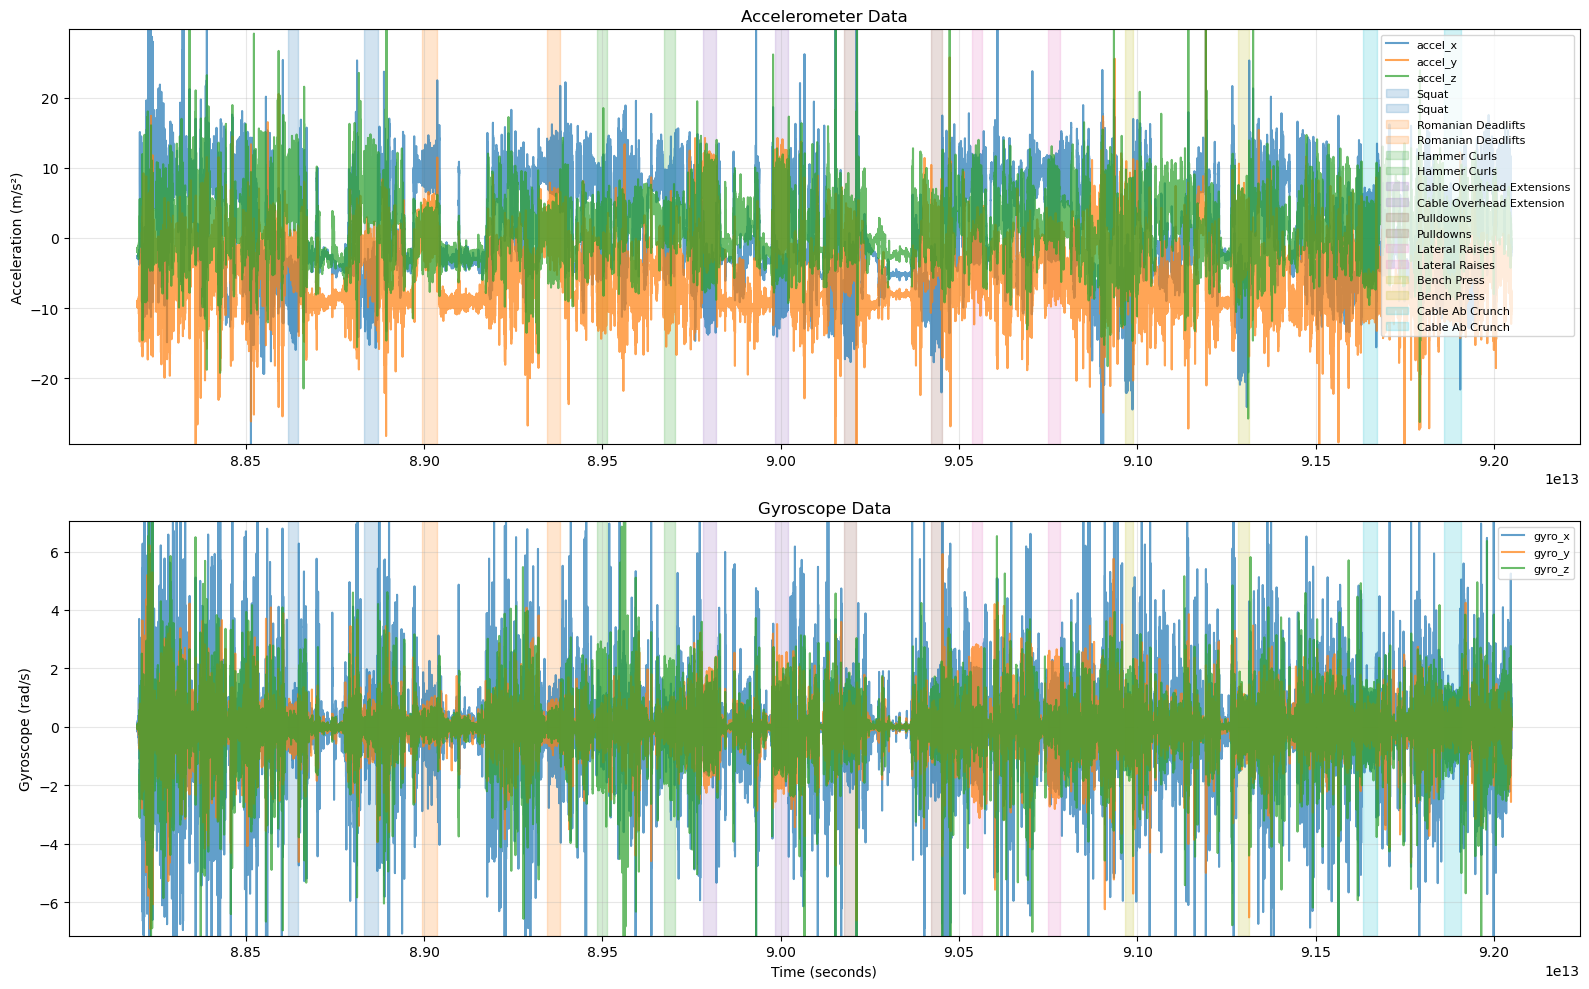

Event synthetic times (ms):
Squat: 88616983365381ms - 88646521365381ms
Squat: 88831563365381ms - 88871183365381ms
Romanian Deadlifts : 88993044365381ms - 89037252365381ms
Romanian Deadlifts : 89345056365381ms - 89380557365381ms
Hammer Curls: 89484099365381ms - 89512299365381ms
Hammer Curls: 89671483365381ms - 89703777365381ms
Cable Overhead Extensions: 89782903365381ms - 89819367365381ms
Cable Overhead Extension: 89984268365381ms - 90021285365381ms
Pulldowns: 90178357365381ms - 90212227365381ms
Pulldowns: 90420265365381ms - 90451599365381ms
Lateral Raises : 90534907365381ms - 90565621365381ms
Lateral Raises : 90749541365381ms - 90782098365381ms
Bench Press: 90964678365381ms - 90987214365381ms
Bench Press: 91282873365381ms - 91311882365381ms
Cable Ab Crunch: 91631473365381ms - 91671014365381ms
Cable Ab Crunch: 91860675365381ms - 91906241365381ms


In [35]:
plot_recording(combined_with_annotations, events_synthetic)

In [36]:
combined_with_annotations.iloc[38101]

timestamp    88958822860854
accel_x           -3.354277
accel_y           -8.966286
accel_z           -3.260903
gyro_x             -0.00733
gyro_y            -0.302989
gyro_z              0.00733
event                  None
Name: 38101, dtype: object

## Add predictions column to combined dataframe

In [37]:
# combined_with_annotations["timestamp"] matches in classification["accel_timestamps"]
def check_combined_classification_alignment(combined, classification):
    combined_timestamps = set(combined['timestamp'])
    for idx, row in classification.iterrows():
        accel_timestamps = set(int(ts) for ts in row['accel_timestamps'].split(';'))
        accel_in_combined = accel_timestamps.issubset(combined_timestamps)
        if not accel_in_combined:
            print(f"Row {idx}: Some accel timestamps not in combined")
    print("Alignment check completed.")

In [38]:
check_combined_classification_alignment(combined_with_annotations, classification)

Row 0: Some accel timestamps not in combined
Row 1: Some accel timestamps not in combined
Alignment check completed.


In [39]:
combined_with_predictions = add_predictions_to_combined(combined_with_annotations, classification)
combined_with_predictions.head(10)

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,event,prediction_float,prediction_binary
0,88195557365381,-2.719813,-9.619903,-1.640028,-0.109956,-0.018326,0.012217,None,0.015665,0.0
1,88195577369342,-2.703054,-9.299079,-1.704672,0.064752,-0.017104,0.015882,None,0.015665,0.0
2,88195597372688,-2.703054,-9.047688,-1.766921,0.009774,-0.021991,0.006109,None,0.015665,0.0
3,88195617381034,-2.767697,-9.334992,-2.023100,-0.064752,-0.045204,0.020769,None,0.015665,0.0
4,88195639398150,-2.832341,-9.112331,-2.047042,-0.094073,-0.068417,0.017104,None,0.015665,0.0
5,88195657396611,-2.703054,-9.351752,-1.711854,-0.135612,-0.085521,0.017104,None,0.015665,0.0
6,88195677397842,-2.767697,-9.550470,-1.620874,-0.046426,-0.062308,0.014661,None,0.015665,0.0
7,88195697408149,-2.588132,-9.270349,-1.587356,-0.030543,-0.035430,0.025656,None,0.015665,0.0
8,88195717428265,-2.604891,-9.311050,-1.750161,-0.076969,-0.012217,0.018326,None,0.015665,0.0
9,88195737452380,-2.731784,-9.519346,-1.860295,-0.109956,0.000000,-0.003665,None,0.015665,0.0


In [40]:
def plot_recording_with_predictions(data):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    time = data["timestamp"]

    # --- Plot 1: Accelerometer data ---
    ax1.plot(time, data['accel_x'], label='accel_x', alpha=0.7)
    ax1.plot(time, data['accel_y'], label='accel_y', alpha=0.7)
    ax1.plot(time, data['accel_z'], label='accel_z', alpha=0.7)

    accel_data = data[['accel_x', 'accel_y', 'accel_z']].values
    accel_min, accel_max = np.percentile(accel_data, [1, 99])
    accel_range = accel_max - accel_min
    ax1.set_ylim([accel_min - 0.5*accel_range, accel_max + 0.5*accel_range])
    ax1.set_ylabel('Acceleration (m/s²)')
    ax1.set_title('Accelerometer Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Gyroscope data ---
    ax2.plot(time, data['gyro_x'], label='gyro_x', alpha=0.7)
    ax2.plot(time, data['gyro_y'], label='gyro_y', alpha=0.7)
    ax2.plot(time, data['gyro_z'], label='gyro_z', alpha=0.7)

    gyro_data = data[['gyro_x', 'gyro_y', 'gyro_z']].values
    gyro_min, gyro_max = np.percentile(gyro_data, [1, 99])
    gyro_range = gyro_max - gyro_min
    ax2.set_ylim([gyro_min - 0.5*gyro_range, gyro_max + 0.5*gyro_range])
    ax2.set_ylabel('Gyroscope (rad/s)')
    ax2.set_title('Gyroscope Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    # --- Plot 3: Predictions ---
    ax3.plot(time, data['prediction_float'], label='Predictions', color='black', linewidth=1.5, alpha=0.7)
    ax3.plot(time, data['prediction_binary'], label='Exercise/ noexercise', color='red', linewidth=1.5, alpha=0.4)
    ax3.axhline(y=0.5, color='red', linestyle='--', label='threshold (0.5)')
    ax3.set_ylabel('Probability')
    ax3.set_xlabel('Time (ms)')
    ax3.set_ylim([-0.1, 1.1])
    ax3.grid(True, alpha=0.3)

    # --- Overlay Event Durations ---
    # 1. Identify where events start/end
    event_col = data['event'].fillna('None')
    event_changes = event_col != event_col.shift()
    data['event_group'] = event_changes.cumsum()

    # 2. Map unique events to colors (FIXED DEPRECATION)
    unique_events = [e for e in event_col.unique() if e != 'None']
    
    # Use the new recommended way to get the colormap
    cmap = plt.get_cmap('tab10') 
    event_to_color = {name: cmap(i % 10) for i, name in enumerate(unique_events)}

    # 3. Iterate through each contiguous block
    for _, group in data.groupby('event_group'):
        evt_name = group['event'].iloc[0]
        
        if pd.isna(evt_name) or evt_name == 'None':
            continue
            
        t_start = group['timestamp'].iloc[0]
        t_end = group['timestamp'].iloc[-1]
        color = event_to_color[evt_name]

        for ax in [ax1, ax2, ax3]:
            ax.axvspan(t_start, t_end, color=color, alpha=0.15)
            
            if ax == ax1:
                ax1.text((t_start + t_end) / 2, ax1.get_ylim()[1], evt_name, 
                        ha='center', va='bottom', color=color, fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()

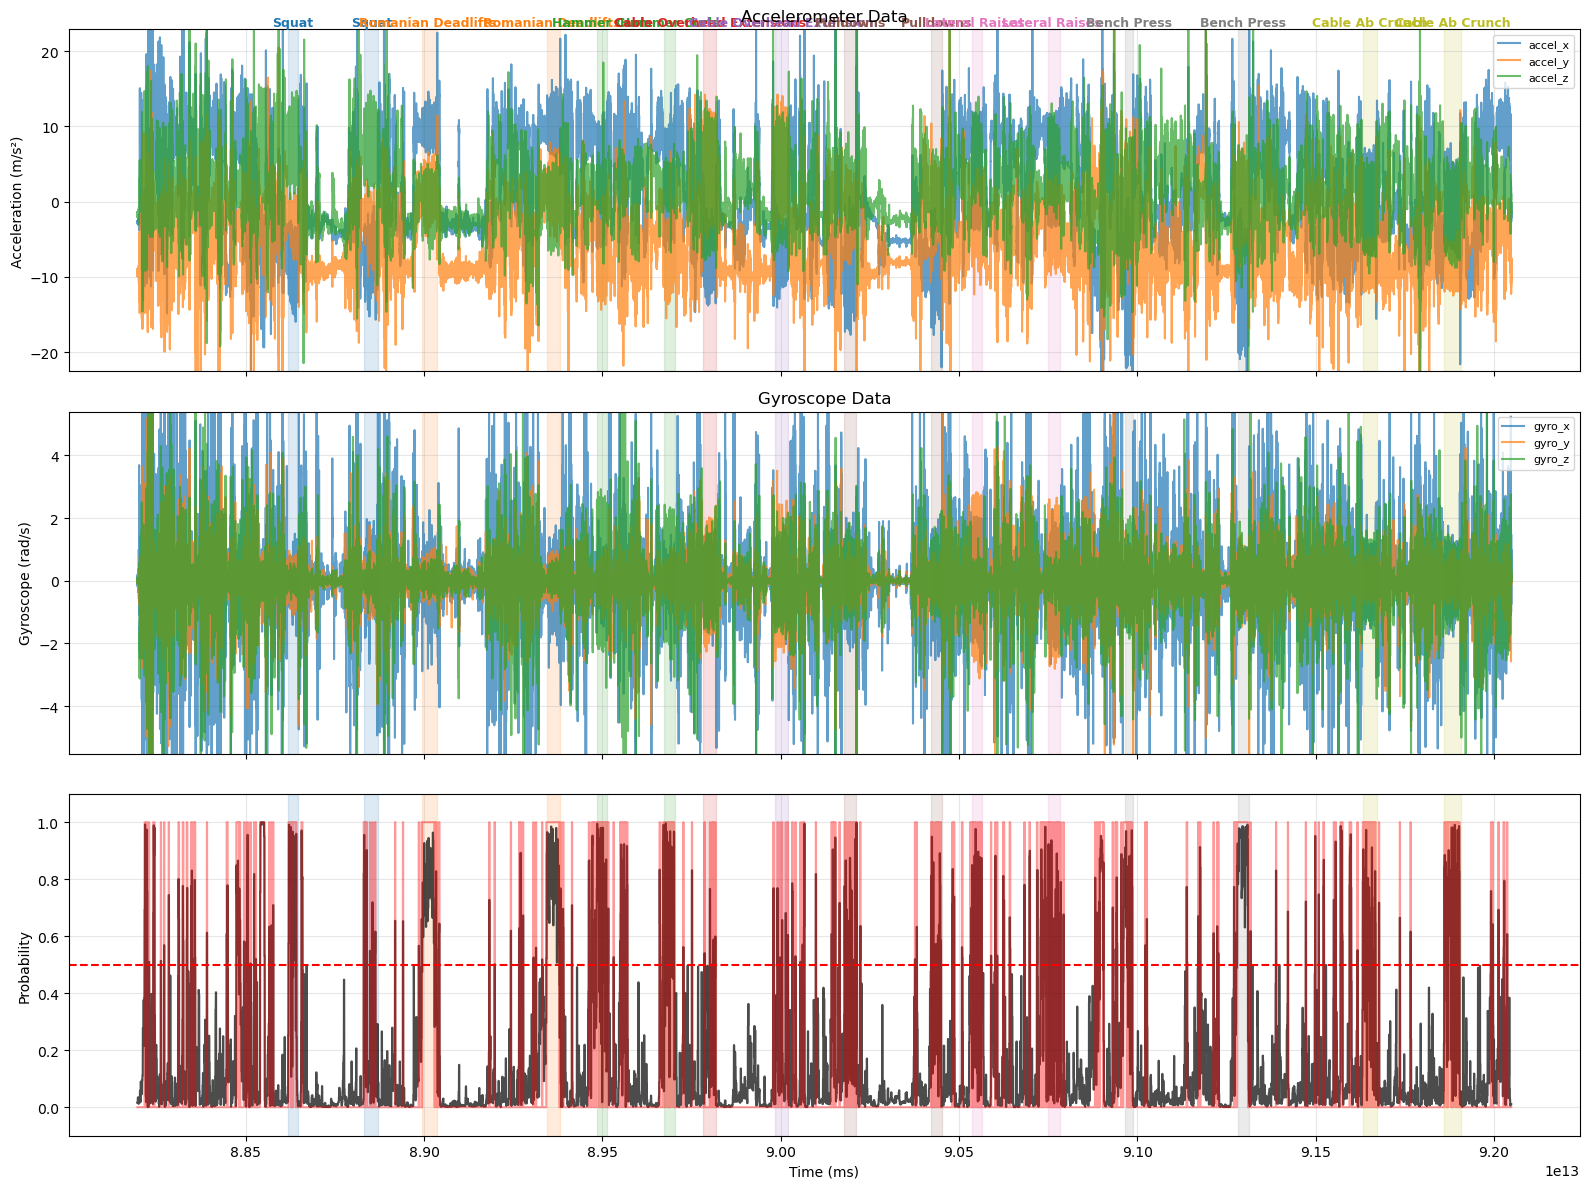

In [41]:
plot_recording_with_predictions(combined_with_predictions)

# smooth out predictions binary

In [42]:
df = combined_with_predictions

In [43]:
df.rolling

<bound method NDFrame.rolling of              timestamp   accel_x   accel_y   accel_z    gyro_x    gyro_y  \
0       88195557365381 -2.719813 -9.619903 -1.640028 -0.109956 -0.018326   
1       88195577369342 -2.703054 -9.299079 -1.704672  0.064752 -0.017104   
2       88195597372688 -2.703054 -9.047688 -1.766921  0.009774 -0.021991   
3       88195617381034 -2.767697 -9.334992 -2.023100 -0.064752 -0.045204   
4       88195639398150 -2.832341 -9.112331 -2.047042 -0.094073 -0.068417   
...                ...       ...       ...       ...       ...       ...   
192292  92048587083069 -1.027113 -8.714894 -0.694318  0.929737 -0.004887   
192293  92048607087492 -0.577003 -8.808268 -0.746991  0.678060  0.014661   
192294  92048627650954 -0.426168 -8.765172 -0.205901  0.496023  0.114843   
192295  92048648629454 -1.211466 -8.111555 -0.179565  0.541227  0.001222   
192296  92048667146108 -1.999158 -7.592013 -0.083797  0.504575  0.156382   

          gyro_z event  prediction_float  prediction_b

In [44]:
df = combined_with_predictions
for idx, row in df.iterrows():
    if idx < 3:
        continue

    previous3 = df.iloc[idx-3:idx-1]["prediction_binary"]

    print(previous3.values)

    if idx > 4:
        break

[0. 0.]
[0. 0.]
[0. 0.]
